In [ ]:
import contextlib
import logging
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import backbones
import common
import metrics
import patchcore
import sampler
import utils
import mvtec as mvtec_dataset
%reload_ext autoreload

logging.basicConfig(level=logging.INFO)
LOGGER = logging.getLogger(__name__)
#once again adapted from https://github.com/amazon-science/patchcore-inspection/blob/main/bin/run_patchcore.py
def run_patchcore(
    data_path,
    subdataset,
    batch_size=2,
    resize=256,
    imagesize=224,
    num_workers=8,
    train_val_split=1.0,
    augment=False,
    backbone_name="wideresnet50",
    layers_to_extract_from=["layer2", "layer3"],
    pretrain_embed_dimension=1024,
    target_embed_dimension=1024,
    patchsize=3,
    patchscore="max",
    patchoverlap=0.0,
    anomaly_scorer_num_nn=5,
    sampler_name="approx_greedy_coreset",
    percentage=0.1,
    gpu_id=0,
    seed=0,
    save_segmentation_images=False,
    save_patchcore_model=False,
    results_path="results",
    log_project="patchcore-project",
    log_group="patchcore-project"
    )  :
    # Create results directory
    run_save_path = utils.create_storage_folder(
        results_path, log_project, log_group, mode="iterate"
    )
 
    device = torch.device(f"cuda:{gpu_id}" if torch.cuda.is_available() else "cpu")
    LOGGER.info(f"Using device: {device}")

    device_context = (
        torch.cuda.device(f"cuda:{gpu_id}")
        if "cuda" in device.type.lower()
        else contextlib.suppress()
    )

    utils.fix_seeds(seed, device)

    train_dataset = mvtec_dataset.MVTecDataset(
        data_path,
        classname=subdataset,
        resize=resize,
        train_val_split=train_val_split,
        imagesize=imagesize,
        split=mvtec_dataset.DatasetSplit.TRAIN,
        seed=seed,
        augment=augment,
    )

    test_dataset = mvtec_dataset.MVTecDataset(
        data_path,
        classname=subdataset,
        resize=resize,
        imagesize=imagesize,
        split=mvtec_dataset.DatasetSplit.TEST,
        seed=seed,
    )

    train_dataloader = torch.utils.data.DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
    )

    test_dataloader = torch.utils.data.DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
    )
    
    train_dataloader.name = f"mvtec_{subdataset}"
    
    dataloaders = {
        "training": train_dataloader,
        "testing": test_dataloader,
    }

    if sampler_name == "identity":
        sampler = patchcore.sampler.IdentitySampler()
    elif sampler_name == "greedy_coreset":
        sampler =  patchcore.sampler.GreedyCoresetSampler(percentage, device)
    elif sampler_name == "approx_greedy_coreset":
        sampler =  patchcore.sampler.ApproximateGreedyCoresetSampler(percentage, device)

    with device_context:
        torch.cuda.empty_cache()
        backbone = backbones.load(backbone_name)
        backbone.name, backbone.seed = backbone_name, None
        
        nn_method = common.FaissNN(True, 8) 
        patchcore_instance = patchcore.PatchCore(device)
        patchcore_instance.load(
            backbone=backbone,
            layers_to_extract_from=layers_to_extract_from,
            device=device,
            input_shape=(3, imagesize, imagesize),
            pretrain_embed_dimension=pretrain_embed_dimension,
            target_embed_dimension=target_embed_dimension,
            patchsize=patchsize,
            featuresampler=sampler,
            anomaly_scorer_num_nn=anomaly_scorer_num_nn,
            nn_method=nn_method,
        )

        LOGGER.info("Training PatchCore model...")
        patchcore_instance.fit(dataloaders["training"])

        LOGGER.info("Testing PatchCore model...")
        scores, segmentations, labels_gt, masks_gt = patchcore_instance.predict(
            dataloaders["testing"]
        )
 
        anomaly_labels = [
            x[1] != "good" for x in dataloaders["testing"].dataset.data_to_iterate
        ]
        
        auroc = metrics.compute_imagewise_retrieval_metrics(
            scores, anomaly_labels
        )["auroc"]
  
        full_pixel_auroc = metrics.compute_pixelwise_retrieval_metrics(
            segmentations, masks_gt
        )["auroc"]

        sel_idxs = []
        for i in range(len(masks_gt)):
            if np.sum(masks_gt[i]) > 0:
                sel_idxs.append(i)
                
        anomaly_pixel_auroc = 0
        if len(sel_idxs) > 0:
            anomaly_pixel_auroc = metrics.compute_pixelwise_retrieval_metrics(
                [segmentations[i] for i in sel_idxs],
                [masks_gt[i] for i in sel_idxs],
            )["auroc"]

        results_dict = {
            "dataset_name": subdataset,
            "instance_auroc": auroc,
            "full_pixel_auroc": full_pixel_auroc,
            "anomaly_pixel_auroc": anomaly_pixel_auroc,
            "raw_scores": scores,
            "raw_segmentations": segmentations,
            "raw_labels": [x[1] for x in dataloaders["testing"].dataset.data_to_iterate],
            "raw_image_paths": [x[2] for x in dataloaders["testing"].dataset.data_to_iterate]
        }
        
        for key, item in {
            "instance_auroc": auroc,
            "full_pixel_auroc": full_pixel_auroc,
            "anomaly_pixel_auroc": anomaly_pixel_auroc
        }.items():
            LOGGER.info("{0}: {1:3.3f}".format(key, item))
        
        if save_segmentation_images:
            image_paths = [
                x[2] for x in dataloaders["testing"].dataset.data_to_iterate
            ]
            mask_paths = [
                x[3] for x in dataloaders["testing"].dataset.data_to_iterate
            ]

            def image_transform(image):
                in_std = np.array(
                    dataloaders["testing"].dataset.transform_std
                ).reshape(-1, 1, 1)
                in_mean = np.array(
                    dataloaders["testing"].dataset.transform_mean
                ).reshape(-1, 1, 1)
                image = dataloaders["testing"].dataset.transform_img(image)
                return np.clip(
                    (image.numpy() * in_std + in_mean) * 255, 0, 255
                ).astype(np.uint8)

            def mask_transform(mask):
                return dataloaders["testing"].dataset.transform_mask(mask).numpy()

            image_save_path = os.path.join(
                run_save_path, "segmentation_images", subdataset
            )
            os.makedirs(image_save_path, exist_ok=True)
            utils.plot_segmentation_images(
                image_save_path,
                image_paths,
                segmentations,
                scores,
                mask_paths,
                image_transform=image_transform,
                mask_transform=mask_transform,
            )
        
        if save_patchcore_model:
            patchcore_save_path = os.path.join(
                run_save_path, "models", subdataset
            )
            os.makedirs(patchcore_save_path, exist_ok=True)
            patchcore_instance.save_to_path(patchcore_save_path)
        
        return results_dict


In [2]:
%autoreload 2
results_front = run_patchcore(
    data_path= r"C:\Thesis\Data\paperclips_sorted",
    subdataset="paperclips_front",
    batch_size=2,
    backbone_name="wideresnet50",
    sampler_name="approx_greedy_coreset",
    gpu_id=0,
    save_segmentation_images=False
)

INFO:__main__:Using device: cuda:0
c:\Users\feder\anaconda3\envs\patchcore-env\lib\site-packages\torch\utils\data\dataloader.py:557: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 6 (`cpuset` is not taken into account), which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(
c:\Users\feder\anaconda3\envs\patchcore-env\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\feder\anaconda3\envs\patchcore-env\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 

In [ ]:
def plot_distribution_with_thresholds_lax(results_dict, good_quantile=95, anomaly_quantile=95, offset=0.05, delta=1e-5):
    scores = np.array(results_dict["raw_scores"])
    labels = np.array(results_dict["raw_labels"])

    good_mask = labels == "good"
    anomaly_mask = labels != "good"
    
    good_scores = scores[good_mask]
    anomaly_scores = scores[anomaly_mask]

    q95_good = np.percentile(good_scores, good_quantile)
    min_anomaly = np.min(anomaly_scores)
    t1 = min(q95_good + offset, min_anomaly - delta)


    q95_anomaly = np.percentile(anomaly_scores, anomaly_quantile)
    t3 = q95_anomaly + offset

    t2 = (t1 + t3) / 2.0


    plt.figure(figsize=(10, 6))
    plt.hist(good_scores, bins=50, alpha=0.5, label="Good", color='blue', density=True)
    plt.hist(anomaly_scores, bins=50, alpha=0.5, label="Anomalous", color='red', density=True)

    plt.axvline(t1, color='green', linestyle='--', linewidth=2, label=f't₁ (Surely Good): {t1:.2f}')
    plt.axvline(t2, color='orange', linestyle='--', linewidth=2, label=f't₂ (Intermediate): {t2:.2f}')
    plt.axvline(t3, color='purple', linestyle='--', linewidth=2, label=f't₃ (Very Sure Anomaly): {t3:.2f}')
    
    plt.xlabel("Anomaly Score")
    plt.ylabel("Density")
    plt.title("Anomaly Score Distribution with Quantile-Based Thresholds")
    plt.legend()
    plt.grid(True)
    plt.show()

    print("Computed quantile-based thresholds:")
    print("t₁ (Surely Good):", t1)
    print("t₂ (Intermediate):", t2)
    print("t₃ (Very Sure Anomaly):", t3)

    results_dict["thresholds"] = {"t1": t1, "t2": t2, "t3": t3}
    return results_dict


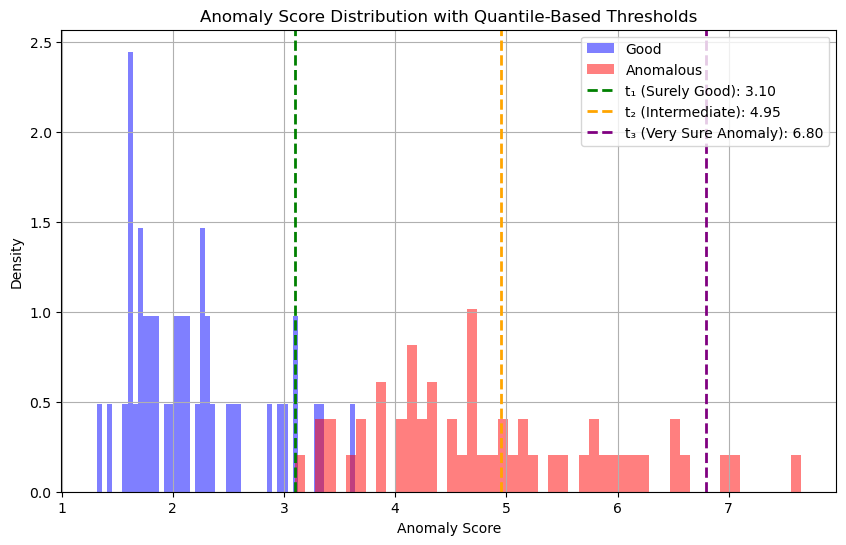

Computed quantile-based thresholds:
t₁ (Surely Good): 3.1011223928833007
t₂ (Intermediate): 4.9481833049011215
t₃ (Very Sure Anomaly): 6.795244216918943


In [8]:
thresholds=plot_distribution_with_thresholds_lax(results_front)